# Why is there a one day periodicity in drifter-altimetry time gap diagnosis ? 
## Necklace

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

________________________
# 1/ Fixed the pearls color/order :
## 11/Get typical temporal variability from drifter velocity

HF
LF
inertial
diurnal
semidiurnal


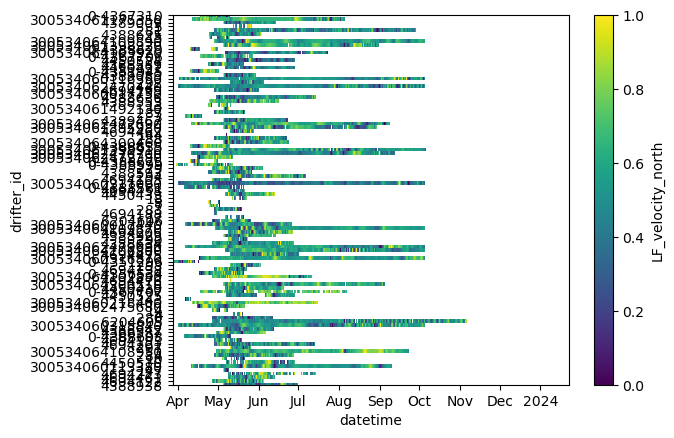

In [31]:
ds = xr.open_dataset('/Users/mdemol/DATA_DRIFTERS/drifters_harmonized_old/L2/all_med_variational_10min_v0.nc').set_coords('drifter_type')
ds['drifter_id'] = ds.drifter_id.astype(str)
def filter_traj(ds, T=20, cutoff = { 'HF':[2.2, 70.95], 'LF': [0.88],'inertial':[1.05, 1.75], 'diurnal' : [0.88, 1.05], 'semidiurnal':[1.9, 2.1],}):
    """Return dataset with filtered trajectories acceleration and coriolis term (inertial, diurnal, semidiurnal)
    T: window length days
    """
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize
    
    # coefficients
    dt = 1/24/6  # 10min in days
    numtaps = int(T / dt)
    pass_zero = False


    # filter
    dss = ds.fillna(0)
    for c in cutoff : 
        if c == 'LF' : pass_zero = True
        #elif c == 'HF' : pass_zero = 'highpass'
        else : pass_zero = False
 
        taps = signal.firwin(numtaps, cutoff=cutoff[c], pass_zero=pass_zero, fs=1 / dt, scale=True)
        dss[c+'_velocity_east'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_east),
            dims=["drifter_id", "datetime"],
            )
        dss[c+'_velocity_north'] = xr.DataArray(
            filtfilt(taps, 1, dss.velocity_north),
            dims=["drifter_id","datetime"],
            )
        dss[c+'_acceleration_east'] = (
            (dss[c+'_velocity_east'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_east.attrs)
        )
        dss[c+'_acceleration_north'] = (
            (dss[c+'_velocity_north'].differentiate("datetime", datetime_unit = '1s'))
            .assign_attrs(**ds.acceleration_north.attrs)
        )
        print(c)
    
    return dss

ds_ = ds.isel(drifter_id = slice(0,100))
dsi = filter_traj(ds_).where(ds_.gap_mask==1)


# Min = 0 + normalized 
min_, max_ = dsi.LF_velocity_north.min('datetime'), dsi.LF_velocity_north.max('datetime')

dso = (dsi.LF_velocity_north - min_)/(max_-min_)
dso['time'] = (dso.datetime - dso.datetime.min())/pd.Timedelta('1d')
dso.plot()

________
## 12/ What if linear dependence ?

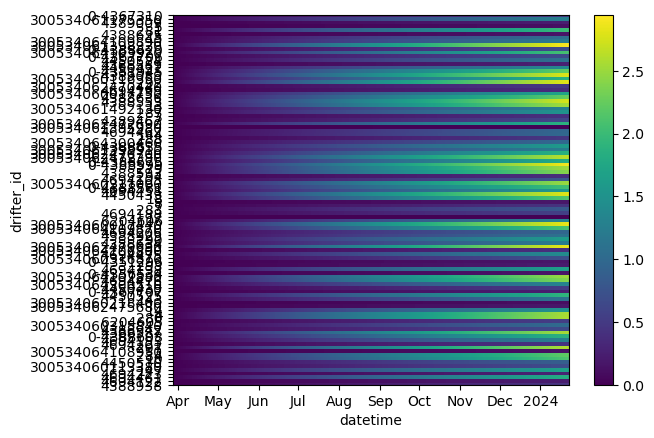

In [41]:
dsl = xr.ones_like(dso)
dsl = dsl*(dsl.time)/100
dsl = dsl * xr.DataArray(data = np.random.rand(len(dsl.drifter_id)), coords = {'drifter_id' :dsl.drifter_id})
dsl.plot()

________
## 13/ What if sinusoide ?

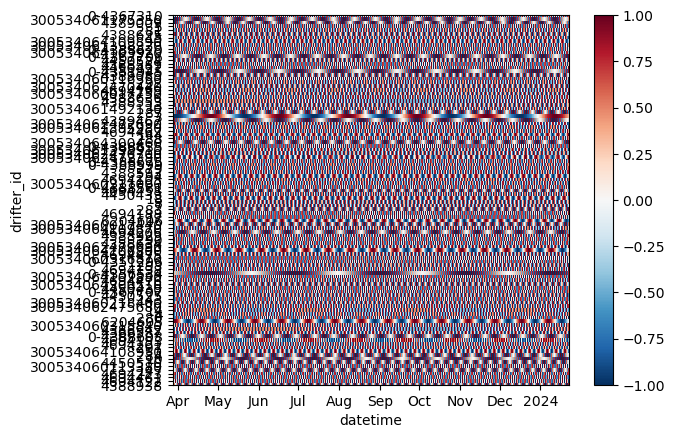

In [77]:
dsn = xr.ones_like(dso)
phi = xr.DataArray(data = np.random.rand(len(dsn.drifter_id))*2*np.pi, coords = {'drifter_id' :dsl.drifter_id})
T = xr.DataArray(data = np.random.rand(len(dsn.drifter_id))*4, coords = {'drifter_id' :dsl.drifter_id})

dsn = dsn*np.sin(2*np.pi*dsn.time/T + phi)
dsn.plot()

# 2/ Build necklaces for all the different swot images : select the drifter points/pearls at +-10 days
## 21/ One drifter

In [42]:
i = 3
dt_drifter = 10/60/24 #10min in days

traj = dso.isel(drifter_id=i).dropna('datetime')
t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
traj['datetime'] = t                            

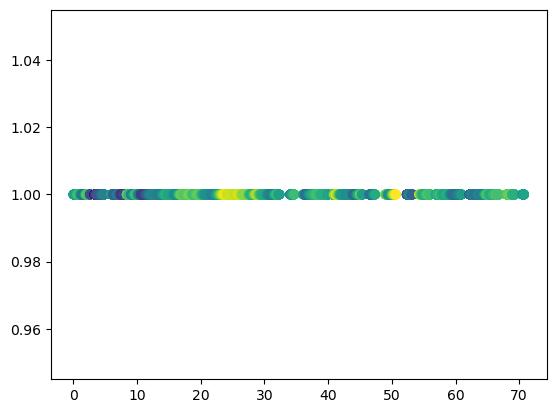

In [43]:
plt.scatter(t, np.ones_like(t), c = traj.values)

In [44]:
def select_traj(traj, tswot):
    tneg =  np.sort(np.arange(0, -10-dt_drifter, -dt_drifter))
    tpos = np.sort(np.arange(dt_drifter, 10, dt_drifter))
    ts = np.concatenate([tneg, tpos])
    tneg =  np.sort(np.arange(0, 10-dt_drifter, -dt_drifter))
    dd = traj.interp(datetime=ts+tswot)
    dd['datetime'] = ts
    return dd
dtswot= 1
Tswot = np.arange(0, 40, dtswot)

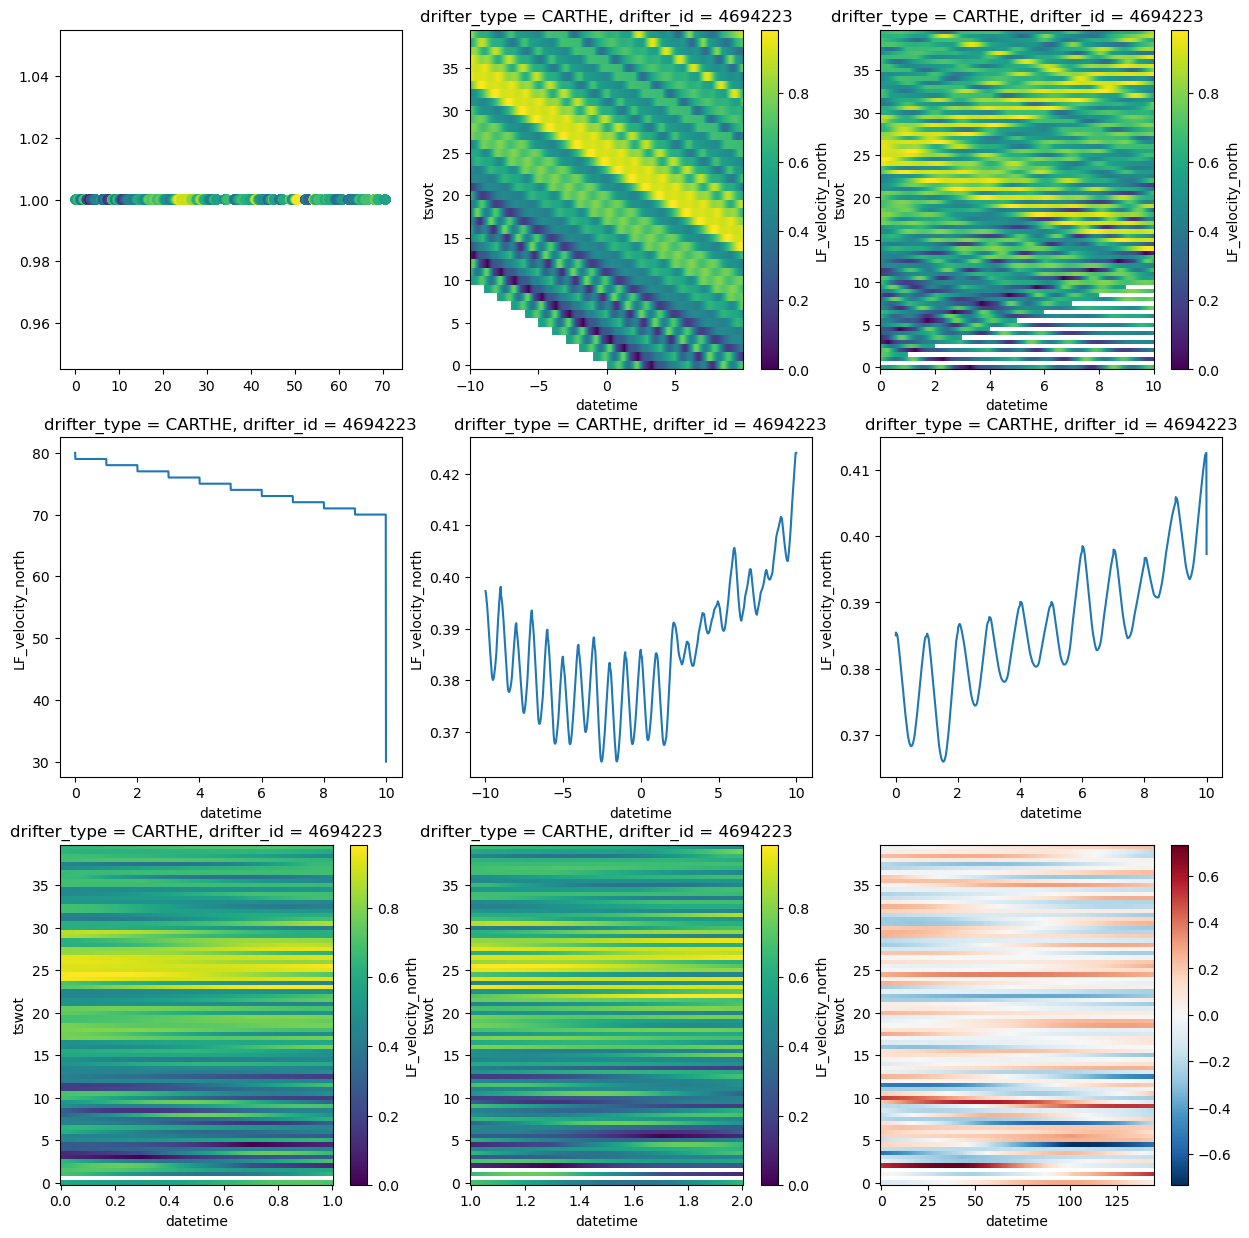

In [75]:
def print_for_one_traj(ds, i):
    dt_drifter = 10/60/24 #10min in days
    fig, axs = plt.subplots(3,3, figsize=(15, 15))
    axs = axs.flatten()
    #select traj
    traj = ds.isel(drifter_id=i).dropna('datetime')
    t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
    traj['datetime'] = t  
    axs[0].scatter(t, np.ones_like(t), c = traj.values)

    def build_necklace(traj, tswot):
        tneg =  np.sort(np.arange(0, -10-dt_drifter, -dt_drifter))
        tpos = np.sort(np.arange(dt_drifter, 10, dt_drifter))
        ts = np.concatenate([tneg, tpos])
        tneg =  np.sort(np.arange(0, 10-dt_drifter, -dt_drifter))
        dd = traj.interp(datetime=ts+tswot)
        dd['datetime'] = ts
        return dd
    
    dtswot= 1
    Tswot = np.arange(0, 40, dtswot)
    
    D = []
    for ts in Tswot :
        D.append(build_necklace(traj, ts))
    dsp = xr.concat(D, pd.Index(Tswot, name = 'tswot'))
    dsp.plot(ax=axs[1])
    
    pos = dsp.where(dsp.datetime >= 0, drop=True)
    neg = dsp.where(dsp.datetime <= 0, drop=True)
    neg['datetime'] = - neg['datetime']
    neg['tswot'] = neg['tswot']+ 0.5
    concat = xr.concat([pos, neg], dim = 'tswot')
    concat = concat.sortby('tswot')
    concat.plot(ax=axs[2])
    concat.count(dim='tswot').plot(ax=axs[3])
    (concat**2).mean('tswot').plot(ax=axs[5])
    (dsp**2).mean('tswot').plot(ax=axs[4])
    #concat.sel(tswot=slice(10, None)).mean('tswot').plot(ax=axs[5])
    
    concat.sel(datetime=slice(0,1)).plot(ax=axs[6])
    concat.sel(datetime=slice(1, 2)).plot(ax=axs[7])
    diff = concat.sel(datetime=slice(0, 1)).values - concat.sel(datetime=slice(1, 2)).values
    
    diff = xr.DataArray(diff, coords={'tswot':np.arange(0, diff.shape[0]/2, 0.5),'datetime':np.arange(diff.shape[1]) })
    diff.plot(ax=axs[8])
    #concat.sel(datetime=slice(2,3)).plot(ax=axs[8])

    return traj, dsp, concat

traj, dsp, concat = print_for_one_traj(dso, 3)

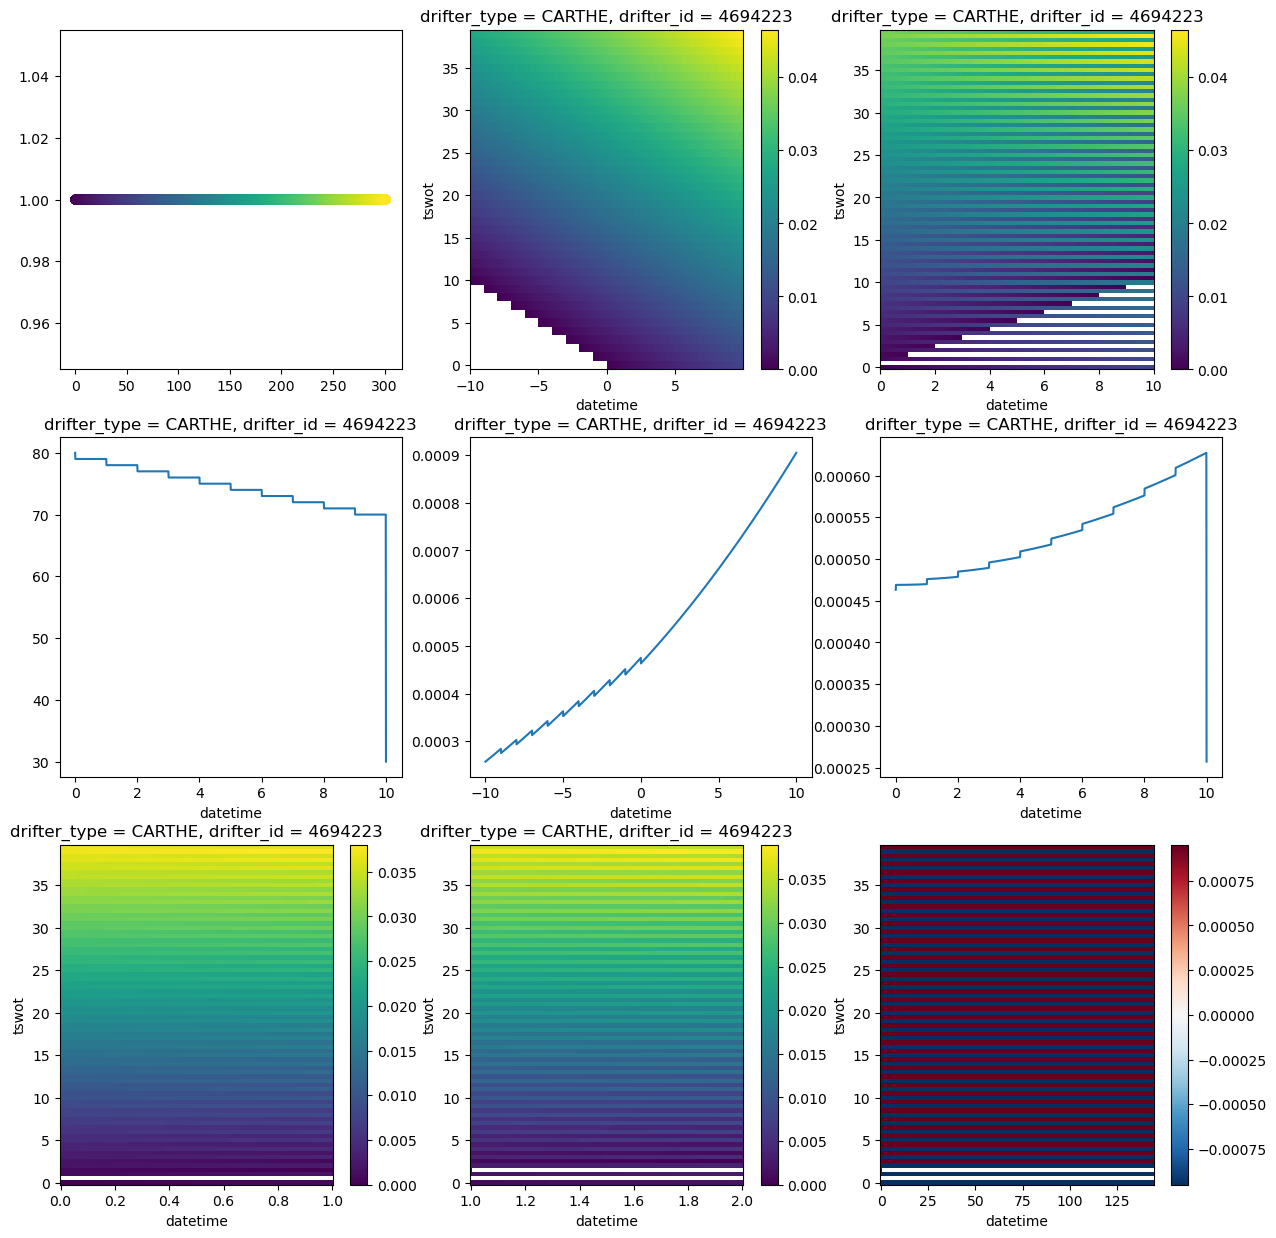

In [76]:
traj, dsp, concat = print_for_one_traj(dsl, 3)

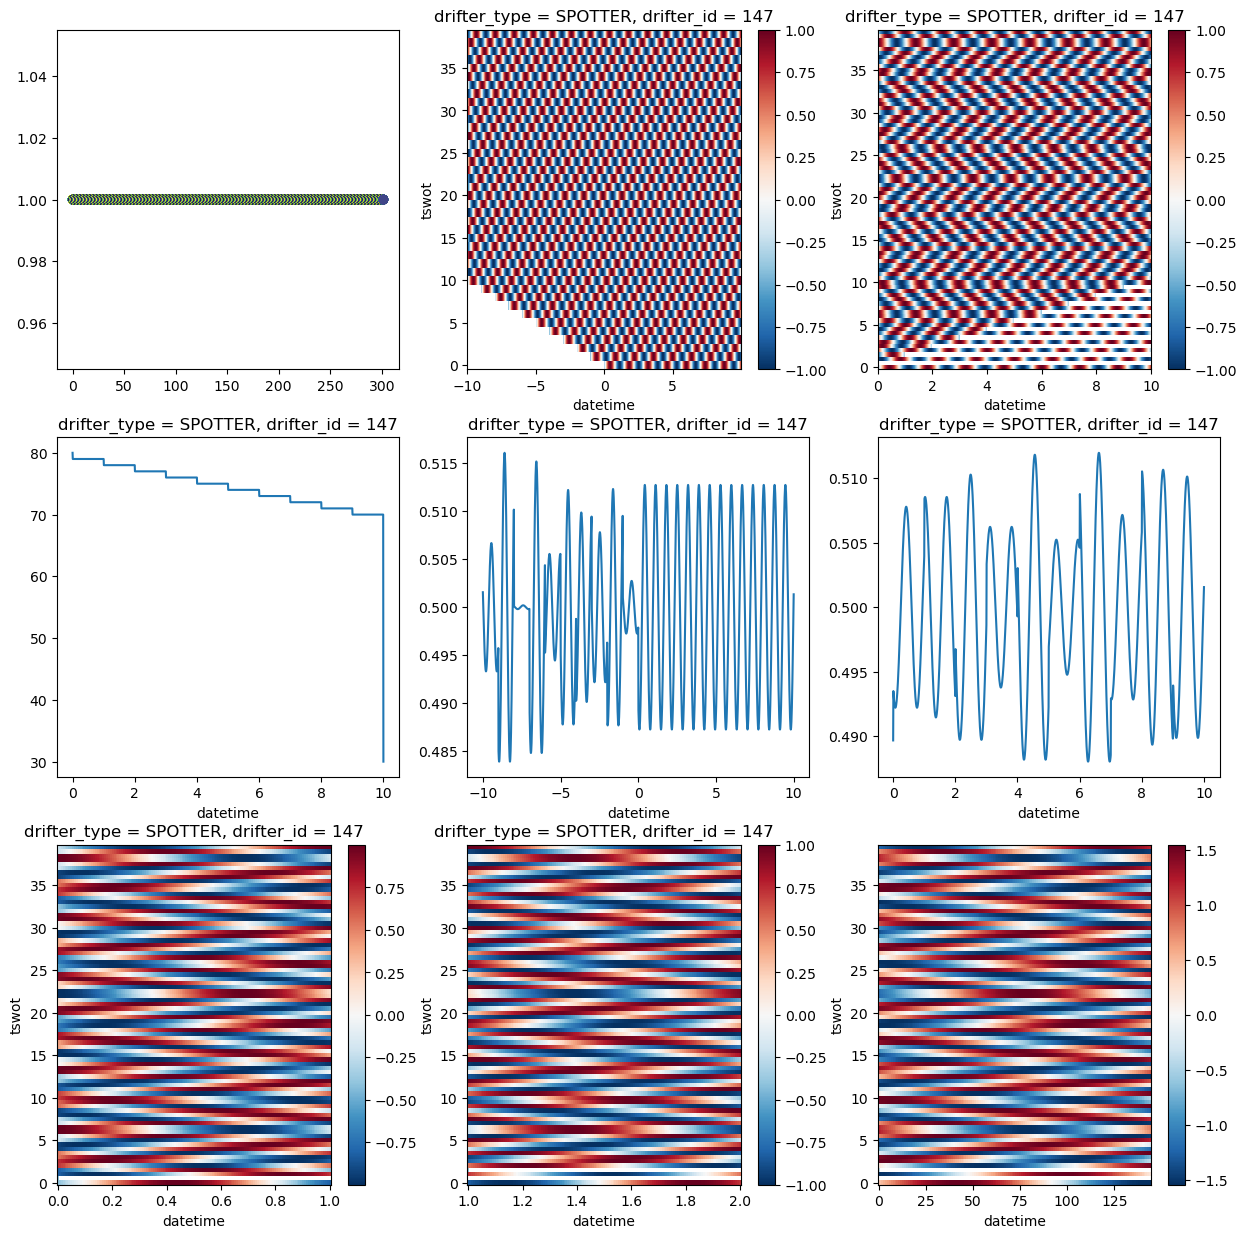

In [80]:
traj, dsp, concat = print_for_one_traj(dsn, 4)

## 22/ For all 

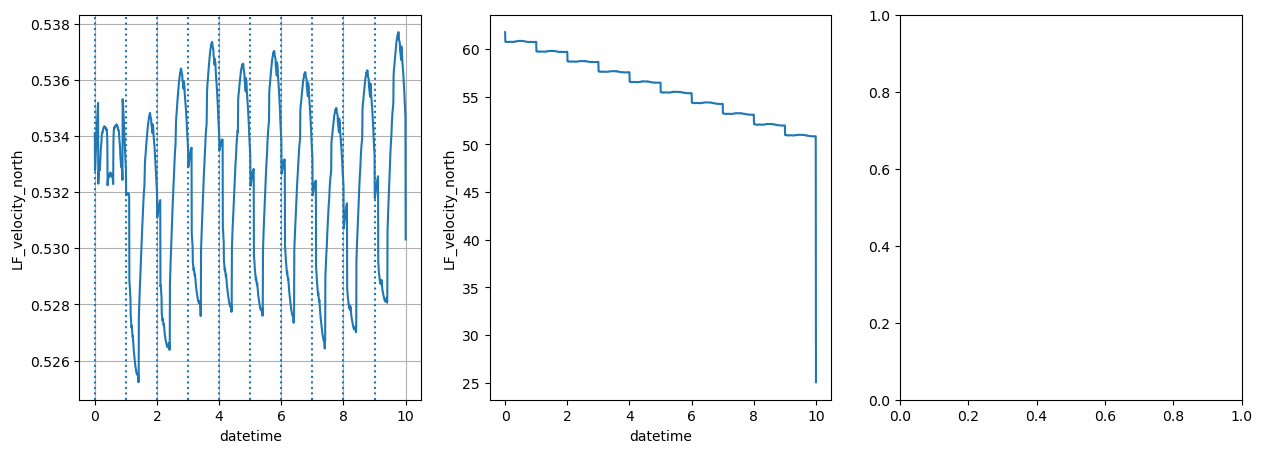

In [95]:
def print_for_all(ds):
    dtswot= 1
    Tswot = np.arange(0, 40, dtswot)
    DD = []
    for d in ds.drifter_id.values :
        traj = ds.sel(drifter_id=d).dropna('datetime')
        try : 
            t = (traj.datetime - traj.datetime.min())/pd.Timedelta('1d')
        except : continue
        traj['datetime'] = t
        D = []
        for ts in Tswot :
            D.append(select_traj(traj, ts))
        DD.append(xr.concat(D, pd.Index(Tswot, name = 'tswot')))
    dsf = xr.concat(DD, dim = 'drifter_id')
    pos = dsf.where(dsf.datetime >= 0, drop=True)
    neg = dsf.where(dsf.datetime <= 0, drop=True)
    neg['datetime'] = - neg['datetime']
    neg['tswot'] = neg['tswot']+ 0.5
    fconcat = xr.concat([pos, neg], dim = 'tswot')

    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    ax=axs[0]
    fconcat.mean('tswot').mean('drifter_id').plot(ax=ax)
    for i in range(0, 10) :
        ax.axvline(i, ls=':')
    ax.grid()

    fconcat.count(dim='tswot').mean('drifter_id').plot(ax=axs[1])
    return dsf, fconcat

dsf, fconcat = print_for_all(dso)   

In [82]:
dsp

<xarray.DataArray (tswot: 40, datetime: 2880)> Size: 922kB
array([[        nan,         nan,         nan, ...,  0.62082489,
         0.64510338,  0.66874733],
       [        nan,         nan,         nan, ..., -0.88982553,
        -0.87507879, -0.8594713 ],
       [        nan,         nan,         nan, ..., -0.27431069,
        -0.30433183, -0.33405362],
       ...,
       [ 0.83965685,  0.82221231,  0.80395903, ..., -0.95605148,
        -0.96477569, -0.97255092],
       [ 0.36923377,  0.39819519,  0.42676493, ...,  0.47373923,
         0.44588951,  0.41760121],
       [-0.98344318, -0.97727674, -0.97014903, ...,  0.77156883,
         0.79113822,  0.80992943]])
Coordinates:
    drifter_type  <U7 28B 'SPOTTER'
    drifter_id    <U15 60B '147'
    time          (tswot, datetime) float64 922kB nan nan nan ... 48.99 48.99
  * datetime      (datetime) float64 23kB -10.0 -9.993 -9.986 ... 9.986 9.993
  * tswot         (tswot) int64 320B 0 1 2 3 4 5 6 7 ... 32 33 34 35 36 37 38 39

In [92]:
TMIN = []
TMAX = []
for d in dso.drifter_id :
    dso_ = dso.sel(drifter_id = d).dropna('datetime')
    try :
        tmin_, tmax_ = dso_.datetime.min(), dso_.datetime.max()
        TMIN.append(tmin_)
        TMAX.append(tmax_)
    except : 
        TMIN.append(0)
        TMAX.append(0)
len(TMIN)

100

In [94]:
dsp

<xarray.DataArray (tswot: 40, datetime: 2880)> Size: 922kB
array([[        nan,         nan,         nan, ...,  0.62082489,
         0.64510338,  0.66874733],
       [        nan,         nan,         nan, ..., -0.88982553,
        -0.87507879, -0.8594713 ],
       [        nan,         nan,         nan, ..., -0.27431069,
        -0.30433183, -0.33405362],
       ...,
       [ 0.83965685,  0.82221231,  0.80395903, ..., -0.95605148,
        -0.96477569, -0.97255092],
       [ 0.36923377,  0.39819519,  0.42676493, ...,  0.47373923,
         0.44588951,  0.41760121],
       [-0.98344318, -0.97727674, -0.97014903, ...,  0.77156883,
         0.79113822,  0.80992943]])
Coordinates:
    drifter_type  <U7 28B 'SPOTTER'
    drifter_id    <U15 60B '147'
    time          (tswot, datetime) float64 922kB nan nan nan ... 48.99 48.99
  * datetime      (datetime) float64 23kB -10.0 -9.993 -9.986 ... 9.986 9.993
  * tswot         (tswot) int64 320B 0 1 2 3 4 5 6 7 ... 32 33 34 35 36 37 38 39